### Итак... Сама суть блокнота сильно прям не измениалсь, но кое что интересное почерпать таки можно. Результаты на моем примере разнятся от тех, что приведены были тут: <br>
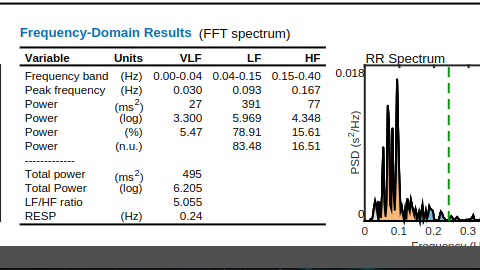
### Однако, я предполагаю что это из за разницы обработки ФПГ на детекцию пиков и конвертации в HRV интервалы, с большей вероятностью это было сделано с помощью heartpy -> `import heartpy as hp`
### Я же лично использовал костыльный метод, предоставленный любезно моим коллегой Владимиром Чеховским, благо его метод не сливает многие пики. (хотя для параметорв все же удобнее само собой эту либу юзать) Далее почти в каждом Селле я буду расписывать что вообще творится...
*Первый пункт - импортируем либы и модули*

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.interpolate import interp1d
from scipy.signal import stft

from scipy.signal import butter, filtfilt, find_peaks
import heartpy as hp

plt.rcParams['figure.figsize'] = (16, 6)

*Второй пункт - подгружаем таблицу с данными (датафрейм)*

In [9]:
df_ppg = pd.read_csv('data_ppg_1.csv', sep=';', skiprows=2)
df_ppg

,Ticks,no_units,uS,kOhms,mV
0,5.322327e+03,0,12.228236,81.777943,0.000000
1,5.328186e+03,0,15.873016,63.000000,0.000000
2,5.329163e+03,0,15.873016,63.000000,0.000000
3,5.330139e+03,0,15.873016,63.000000,0.000000
4,5.331116e+03,0,15.873016,63.000000,0.000000
...,...,...,...,...,...
1048568,1.029865e+06,1,4.832102,206.949287,1487.179487
1048569,1.029866e+06,1,4.832102,206.949287,1489.377289
1048570,1.029867e+06,1,4.832102,206.949287,1490.842491
1048571,1.029868e+06,1,4.832102,206.949287,1492.307692


*Третий - берем столбец-вектор со значениями напряжения*

In [10]:
data_ppg = df_ppg['mV'].to_numpy()
data_ppg.shape

(1048573,)

*Четвертый - задаем базовые параметры, как частота дсикретизации, диапазон отображения графика и смещение - чтобы убрать бяку в начале*

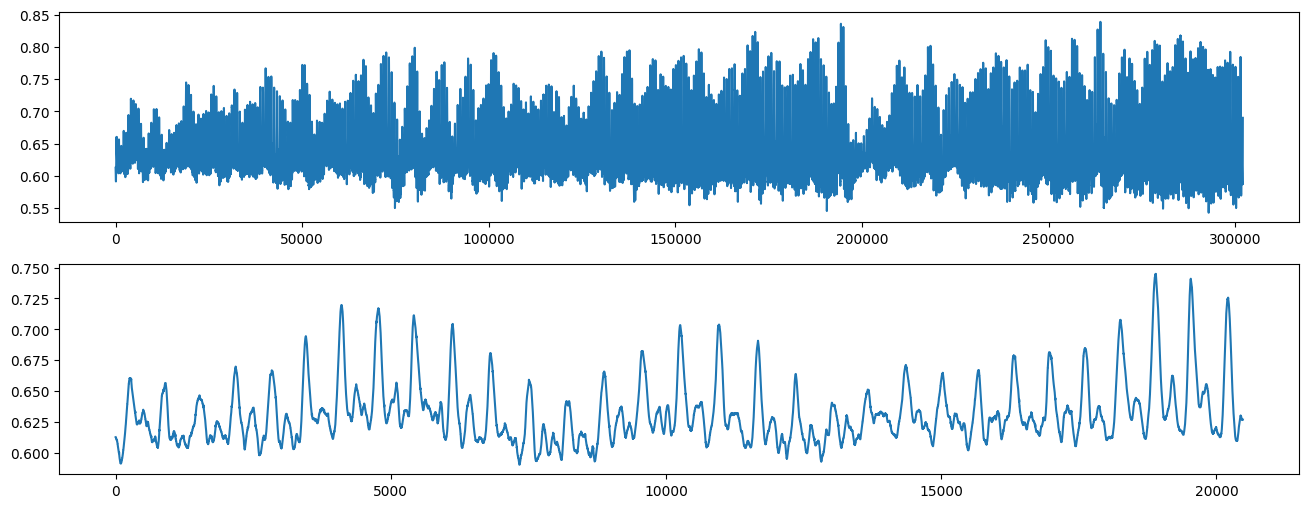

In [11]:
data = (data_ppg - data_ppg.min()) / (data_ppg.max() - data_ppg.min())

fs = 1024 # Hz
band_window =  5 * 60 # seconds
bias_start = fs * 5 # plots

plt.subplot(211)
plt.plot(data[bias_start:int(len(data) / fs*band_window)])
plt.subplot(212)
plt.plot(data[bias_start:bias_start+fs*20])
plt.show()

*Пятый - то, о чем я в начале упомянул... алгоритм Вовы*

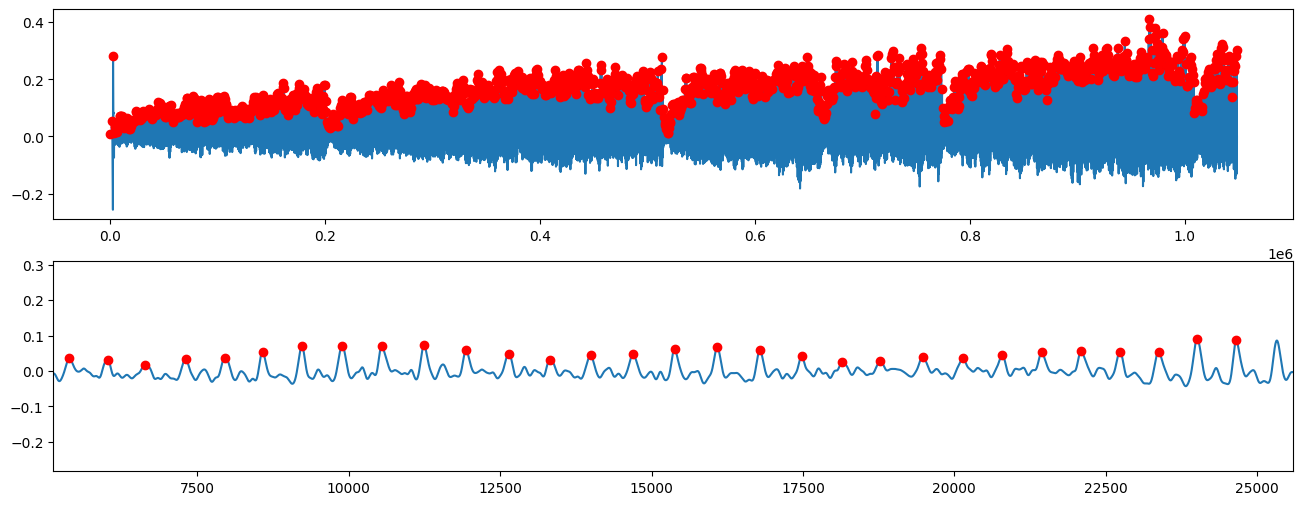

RR-расстояния между пиками, в секундах: [1.65429688 0.91894531 0.97558594 ... 0.69726562 0.6796875  0.6875    ]


In [12]:
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

def detect_r_peaks(ppg_signal, fs, lowcut=0.5, highcut=10.0):
    # Создаём и применяем полосовой фильтр
    b, a = butter_bandpass(lowcut, highcut, fs)
    filtered_signal = filtfilt(b, a, ppg_signal)

    peaks, _ = find_peaks(
        filtered_signal,
        distance=fs * 0.5,
        height=np.mean(filtered_signal)
    )
    
    return peaks, filtered_signal

def compute_rr_dist(r_peaks, fs):
    r_peaks_times = r_peaks / fs  # в секундах
    rr_intervals = np.diff(r_peaks_times)
    return r_peaks_times, rr_intervals


ppg_rpeaks, ppg_filtered = detect_r_peaks(
    data,fs
)
r_peaks_times, rr_intervals = compute_rr_dist(
    ppg_rpeaks, fs
)

plt.subplot(211)
plt.plot(ppg_filtered)
plt.plot(ppg_rpeaks, ppg_filtered[ppg_rpeaks], "ro")
plt.subplot(212)
plt.plot(ppg_filtered[0:int(len(ppg_filtered) / 10)])
# plt.plot(ppg_example_finger[0:int(len(ppg_example_finger) / 10)])
plt.plot(ppg_rpeaks[0:35], ppg_filtered[ppg_rpeaks[0:35]], "ro")
plt.xlim(bias_start,bias_start+fs*20)
plt.show()

print('RR-расстояния между пиками, в секундах:', rr_intervals)

*Шестой - получив данные RR-интеравлов, необходимо их интерполировать с указаной частотой в мануале - 4 Гц. Потому что иначе это тупо массив, без фиксированных по временной линии оси, а так она преобретает равномерное распределение с шагом в 0.25 секунд... И да мы получаем новую частоту дискретизации - 4 Гц* <br><br>
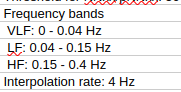<br>
*Еще взял свою старую добрую функцию нормальзации и преобразования сигнала в приближенный набор частот, используя дискретное преобразование вейвлета Дебоши, отчасти больше выпендреш, якобы полосовой фильтр можно тоже было применить и не парится, но зато первый дает коэффициенты приближающие - основная гармоника фильтрации, и вторичные уровни детализации - ВЧ остатки*

### Если что, после самого последнего селла с харжпаем, запускать отсюда потом, после получение из него RR-интервалов

(1491,)
(1491,)


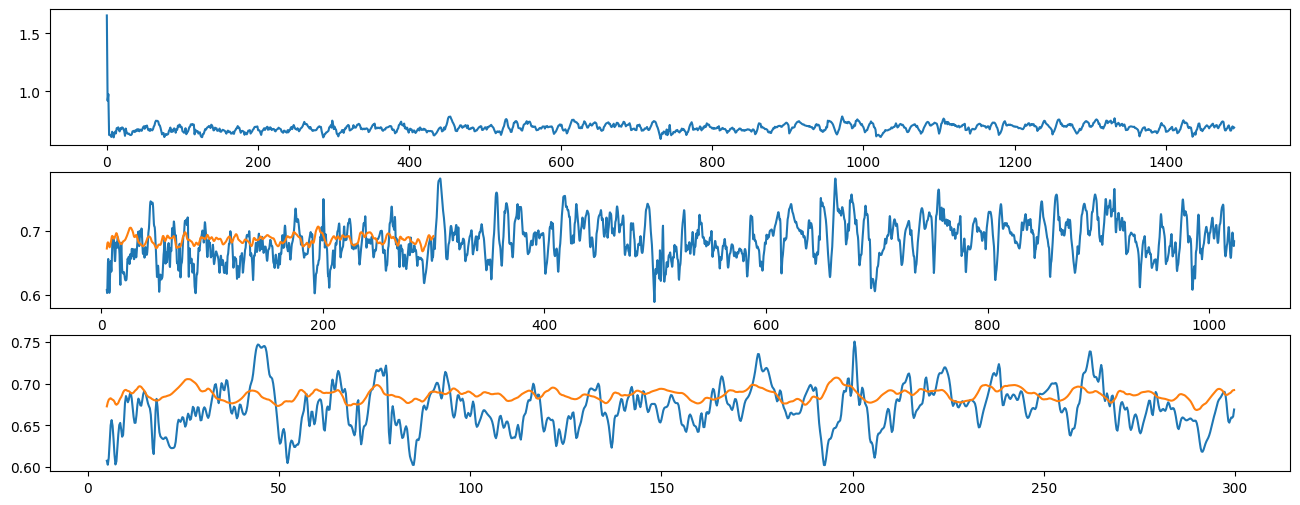

(1491,)
(4091,)


In [13]:
def interpolate_rr(rr_intervals, fs_interp=4.0):
    # Создаём временные метки для каждого удара сердца
    rr_timestamps = np.cumsum(rr_intervals) # считаем накопительную сумму или что то типа интеграла на каждом шаге
    # было [0.8, 0.9, 1.0], то будет [0.8, 1.7, 2.7]
    rr_timestamps = np.insert(rr_timestamps, 0, 0.0)[:-1]  # начало с 0, без последнего, мы сдвинули индексы

    print(rr_timestamps.shape) # проверяем на равенсво шейпов
    print(rr_intervals.shape)

    # Создаём равномерную временную ось
    interp_times = np.arange(0, rr_timestamps[-1], 1/fs_interp)

    # ЫЫГЫГГЫГЫГЫГЫГЫ Интерполяция) 
    f = interp1d(rr_timestamps, rr_intervals, kind='cubic', fill_value='extrapolate')
    rr_interp = f(interp_times)

    return interp_times, rr_interp

#### А вот тут отдельно расскажу что за "Вейвлетный Дебош" я тут устроил в коде..
# То, что снизу этот вейвлет по исследованиям лучше всего лежит центральной частотой под наши интревалы. "db4"
# Что вообще за уровни и как это работает. В общем, уровни определяют насколько глубоко и насколько диапазон фильрации будет иметь низкую частотность
# Причем диапазон считается так: [FS/(2^(I+1));FS/(2^(I))], где I-уровень нашего дискретного преобразования. Если мы подставим это все ниже как в коде (от 3 до 4), 
# будет ясно что мы берем бэнд от 0.0625 до 0.5, что впринципи нормально, учитывая слгаживание.
def soft_peak(ppg_signal, wavelet='db4', level=8):

    coeffs = pywt.wavedec(ppg_signal, wavelet, level=level)

    coeffs_filtered = [coeffs[1]]  
    for i in range(1, len(coeffs)):
        coeffs_filtered.append(np.zeros_like(coeffs[i]))

    cleaned_signal = pywt.waverec(coeffs_filtered, wavelet)
    cleaned_signal = cleaned_signal[:len(ppg_signal)]

    return cleaned_signal

fs_hrv = 4.0
low_l = 3
high_l = 5

interp_times, rr_interp = interpolate_rr(rr_intervals, fs_interp=fs_hrv)

amount_aprox_rr_LF_HF = np.zeros_like(soft_peak(rr_interp, level=4))

for i in range(low_l, (high_l+1)):
    amount_aprox_rr_LF_HF += soft_peak(rr_interp, level=i)

# усредняем результаты
amount_aprox_rr_LF_HF /= ((high_l+1) - low_l) 

bias_mean = np.mean(rr_interp[int(fs_hrv*5):])

plt.subplot(311)
plt.plot(rr_intervals)
plt.subplot(312)
plt.plot(interp_times[int(fs_hrv*5):], rr_interp[int(fs_hrv*5):])
plt.plot(interp_times[int(fs_hrv*5):int(fs_hrv*60*5)], bias_mean+amount_aprox_rr_LF_HF[int(fs_hrv*5):int(fs_hrv*60*5)])
plt.subplot(313)
plt.plot(interp_times[int(fs_hrv*5):int(fs_hrv*60*5)], rr_interp[int(fs_hrv*5):int(fs_hrv*60*5)])
plt.plot(interp_times[int(fs_hrv*5):int(fs_hrv*60*5)], bias_mean+amount_aprox_rr_LF_HF[int(fs_hrv*5):int(fs_hrv*60*5)])
plt.show()

print(rr_intervals.shape)
print(rr_interp.shape)

### Вот, это для сравнения с ПДФ-кой, если приглядется, видно что там слгажены участки местами, потому что дефолтный ХардПай скорее всего проигнорил их
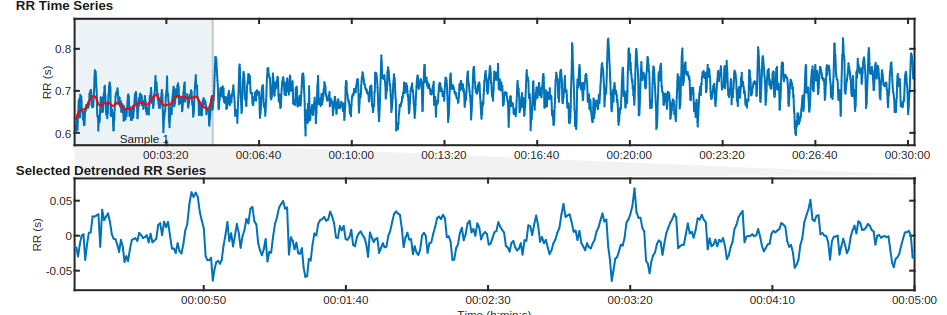

*Седьмой - наши любимые анализаторы сигналов: вейвлеты, Фурье, Оконное Фурье преобразование*
*Видно что вейвлеты (за что я их и люблю) - дают сразу многомерное представление о всем сигнале, а именно локализация по времени и частотам одновременно, по спектрограмме Оконного Фурье-преобразования также можно судить о сходстве анализа и удачной апроскиммации данных между вейвлетами, причем последние опять же отчетливее выражают инфу. И само БПФ (Быстрое преобразование Фурье) "(прошу извинить меня за расписания этой понятной аббревиатуры, привычка)" - также дает анализ сигнала уже на всем окне, с утерянным временем, но да ладно*

***О да, кстати... с переменной `points_per_hz` можно поиграться, уменьшая колличество точек и вдобавок интерполируя, тем самым приближая оконному преобразованию Фурье сигнал, Надеюсь всю прелесть спектрограмм, а точнее их разницу будет видно*** (Поставить 300 разрешение - будет сильно плотная активация, теи самым мы будет упираться спектром в начало вечно)

П.С. - вторая спектрограмма это так, чтобы выразительннее смотрелось усиление через логарифм. И все.

1.0
(49,)
(49,)
Peak in range 0.04-0.15 Hz: 0.02126384763618543 at 0.0925 Hz
Peak in range 0.15-0.4 Hz: 0.012309858319624048 at 0.154375 Hz


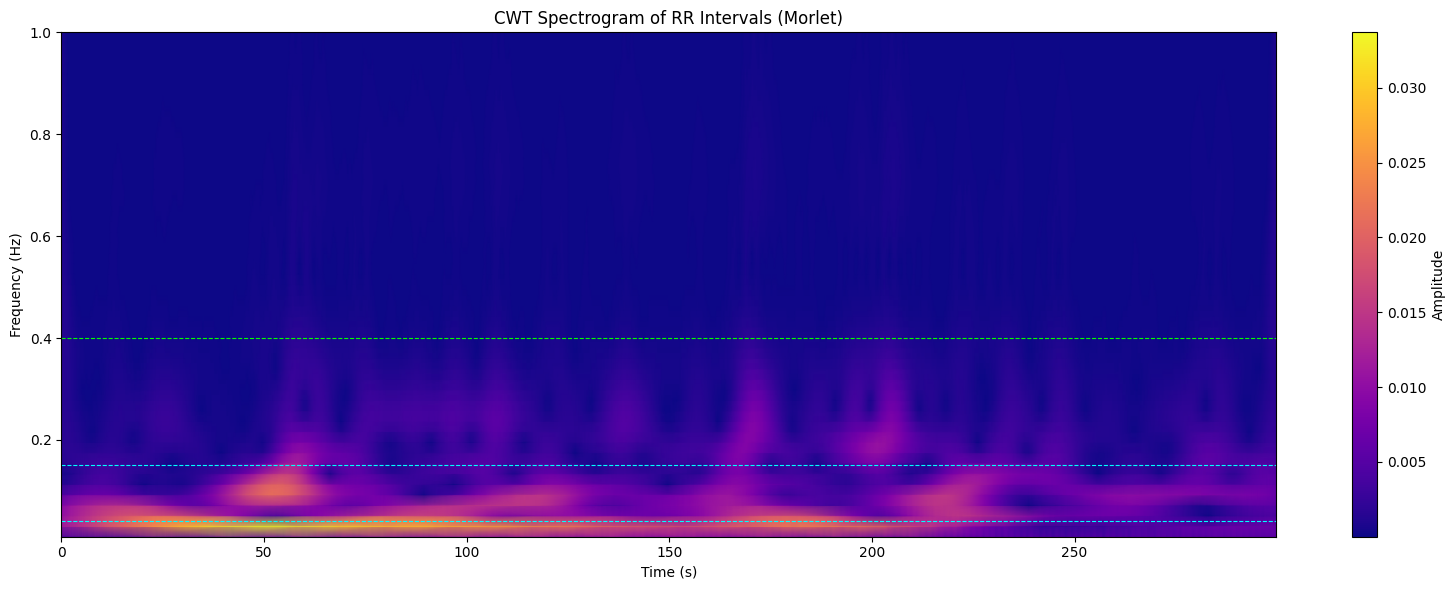

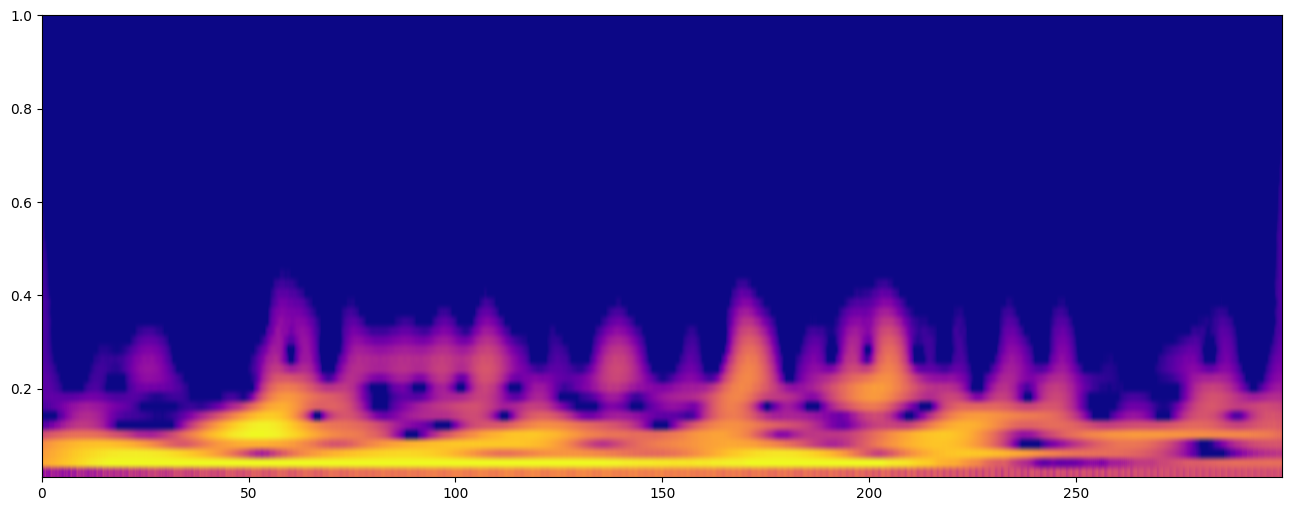

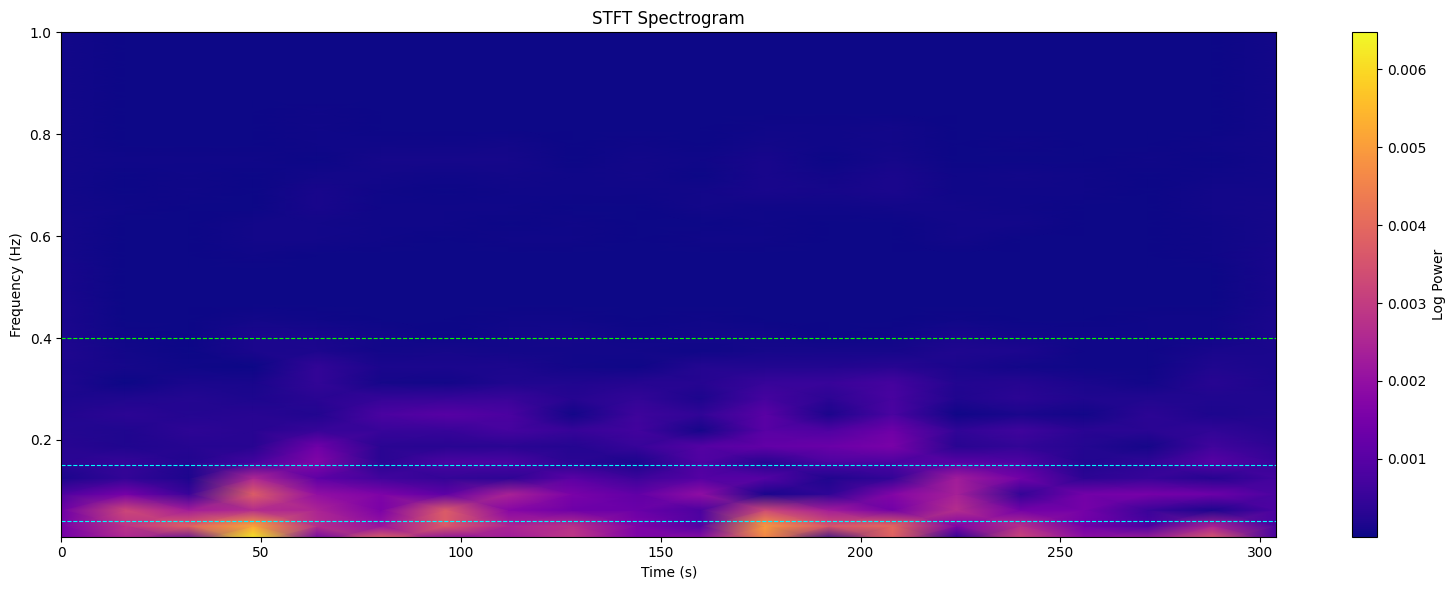

Peak in range 0.04-0.15 Hz: 0.003774225351559549 at 0.09375 Hz
Peak in range 0.15-0.4 Hz: 0.0016950484966393863 at 0.15625 Hz


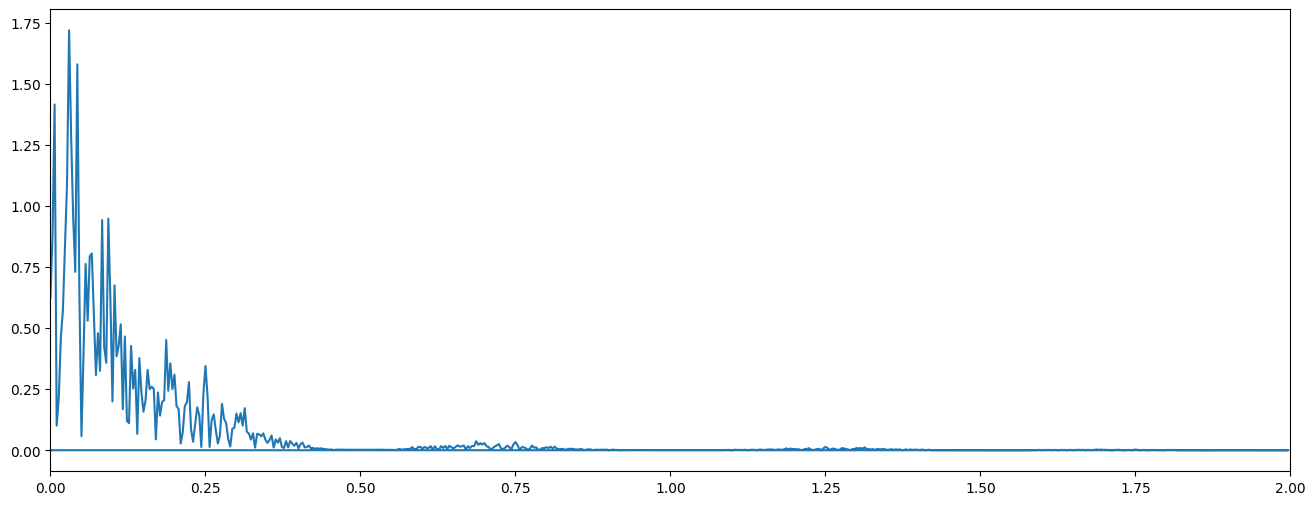

Peak in range 0.04-0.15 Hz: 1.580004080700262 at 0.043333333333333335 Hz
Peak in range 0.15-0.4 Hz: 0.45175279819533903 at 0.18666666666666668 Hz


In [14]:
def plot_cwt_rr_spectrogram(rr_interp, fs_interp=4.0, f_min=0.01, f_max=1.0, points_per_hz=300):
    # Создание частотной оси
    num_freqs = int((f_max - f_min) * points_per_hz)
    frequencies = np.linspace(f_min, f_max, num=num_freqs)

    wavelet = 'cmor1.5-1.0'  
    central_freq = pywt.central_frequency(wavelet)
    print(central_freq)
    scales = central_freq * fs_interp / frequencies

    coefs, freqs = pywt.cwt(rr_interp, scales, wavelet, sampling_period=1/fs_interp)


    power_avg = np.max(np.abs(coefs), axis=1)
    print(power_avg.shape)
    print(freqs.shape)

    peak_range_1 = (freqs >= 0.04) & (freqs <= 0.15)
    peak_1 = np.max(power_avg[peak_range_1])
    peak_freq_1 = freqs[peak_range_1][np.argmax(power_avg[peak_range_1])]

    peak_range_2 = (freqs >= 0.15) & (freqs <= 0.4)
    peak_2 = np.max(power_avg[peak_range_2])
    peak_freq_2 = freqs[peak_range_2][np.argmax(power_avg[peak_range_2])]

    print(f"Peak in range 0.04-0.15 Hz: {peak_1} at {peak_freq_1} Hz")
    print(f"Peak in range 0.15-0.4 Hz: {peak_2} at {peak_freq_2} Hz")

    t = np.arange(len(rr_interp)) / fs_interp

    plt.pcolormesh(t, freqs, np.abs(coefs), shading='gouraud', cmap='plasma')
    plt.ylim(f_min, f_max)
    plt.colorbar(label='Amplitude')
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (s)')
    plt.title('CWT Spectrogram of RR Intervals (Morlet)')

    plt.axhline(0.04, color='cyan', linestyle='--', linewidth=0.8)
    plt.axhline(0.15, color='cyan', linestyle='--', linewidth=0.8)
    plt.axhline(0.4, color='lime', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    plt.show()

    power_log = np.log10(np.abs(coefs) + 1e-6)
    plt.imshow(power_log, aspect='auto', cmap='plasma',
           extent=[t[0], t[-1], freqs[-1], freqs[0]],
           vmin=np.percentile(power_log, 70),
           vmax=np.percentile(power_log, 99))
    plt.gca().invert_yaxis()
    plt.show()




amount_aprox_rr_LF_HF_banded = amount_aprox_rr_LF_HF[int(fs_hrv*60*5):int(fs_hrv*60*10)] # 60 - секунды, 5 или 10 - минуты, это окно от всей сессии

plot_cwt_rr_spectrogram(amount_aprox_rr_LF_HF_banded, fs_interp=4.0, points_per_hz=50)



freqs, t, Zxx = stft(amount_aprox_rr_LF_HF_banded, fs=4.0, nperseg=128)
Zxx_abs = np.abs(Zxx)
plt.pcolormesh(t, freqs, Zxx_abs, shading='gouraud', cmap='plasma')
plt.title('STFT Spectrogram')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Log Power')
plt.ylim(0.01, 1.0)

plt.axhline(0.04, color='cyan', linestyle='--', linewidth=0.8)
plt.axhline(0.15, color='cyan', linestyle='--', linewidth=0.8)
plt.axhline(0.4, color='lime', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

power_line = np.max(np.abs(Zxx_abs), axis=1)

power_avg = np.abs(power_line)

peak_range_1 = (freqs >= 0.04) & (freqs <= 0.15)
peak_1 = np.max(power_avg[peak_range_1])
peak_freq_1 = freqs[peak_range_1][np.argmax(power_avg[peak_range_1])]

peak_range_2 = (freqs >= 0.15) & (freqs <= 0.4)
peak_2 = np.max(power_avg[peak_range_2])
peak_freq_2 = freqs[peak_range_2][np.argmax(power_avg[peak_range_2])]

print(f"Peak in range 0.04-0.15 Hz: {peak_1} at {peak_freq_1} Hz")
print(f"Peak in range 0.15-0.4 Hz: {peak_2} at {peak_freq_2} Hz")



fft_result = np.fft.fft(amount_aprox_rr_LF_HF_banded)
freqs = np.fft.fftfreq(len(amount_aprox_rr_LF_HF_banded), d=1 / 4.0)

plt.subplot(111)
plt.plot(freqs, np.abs(fft_result))
plt.xlim(0,2)
plt.show()

power_avg = np.abs(fft_result)

peak_range_1 = (freqs >= 0.04) & (freqs <= 0.15)
peak_1 = np.max(power_avg[peak_range_1])
peak_freq_1 = freqs[peak_range_1][np.argmax(power_avg[peak_range_1])]

peak_range_2 = (freqs >= 0.15) & (freqs <= 0.4)
peak_2 = np.max(power_avg[peak_range_2])
peak_freq_2 = freqs[peak_range_2][np.argmax(power_avg[peak_range_2])]

print(f"Peak in range 0.04-0.15 Hz: {peak_1} at {peak_freq_1} Hz")
print(f"Peak in range 0.15-0.4 Hz: {peak_2} at {peak_freq_2} Hz")


*Восьмой, Хардпай..да, снизу видна его "прелесть" обработки, тем не менее можно будет затестить его интервалы RR и кинуть в код выше перед Дебоши*

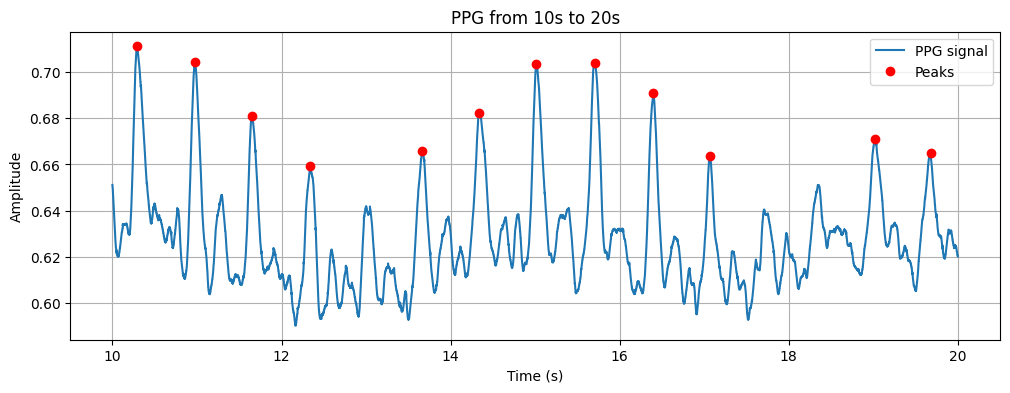

In [15]:
wd, m = hp.process(data, sample_rate=fs)
# # Визуализация
# hp.plotter(wd, m)
# plt.show()
# Определи границы окна (в секундах)
start_sec = 10
end_sec = 20

# Переводим в индексы
start_idx = int(start_sec * fs)
end_idx = int(end_sec * fs)

# Вырезаем нужный участок сигнала
segment = data[start_idx:end_idx]

# Находим пики внутри сегмента (локально)
# Можно heartpy или отдельно, но здесь вручную:
local_peaks = [p - start_idx for p in wd['peaklist'] if start_idx <= p < end_idx]

# Время (в секундах) для оси X
time_axis = np.linspace(start_sec, end_sec, len(segment))

# Рисуем
plt.figure(figsize=(12, 4))
plt.plot(time_axis, segment, label='PPG signal')
plt.plot(time_axis[local_peaks], segment[local_peaks], 'ro', label='Peaks')
plt.title(f'PPG from {start_sec}s to {end_sec}s')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

# # Получение RR (в секундах)
# rr = [r / 1000 for r in wd['RR_list']]

# plt.figure(figsize=(16, 8))
# plt.subplot(211)
# plt.plot(rr)
# plt.show()

rr_intervals = wd['RR_list']